In [27]:
import jax.numpy as jnp
from jax import random, jit, lax
from jax_md import space, simulate

displacement_fn, shift_fn = space.free()

R0 = jnp.array([[0.0, 0.0],[1.0,1.0]], dtype=jnp.float32)

F_ext = jnp.array([[10.0, 0]], dtype=jnp.float32)

def force_fn(R):
    return jnp.broadcast_to(F_ext,R.shape)

dt = 1e-3
kT = 1.0
gamma = 1.0

init_fn, step_fn = simulate.brownian(
    force_fn,
    shift_fn,
    dt=dt,
    kT=kT,
    gamma=gamma,
)
step_fn = jit(step_fn)

state = init_fn(random.PRNGKey(0), R0, mass=1.0)

def one_step(state, _):
    state = step_fn(state)
    return state, state.position

state, trajectory = lax.scan(one_step, state, jnp.arange(1000))

print(trajectory.shape)
print(trajectory[-1, 0]) 

(1000, 2, 2)
[ 9.543046  -1.4912395]


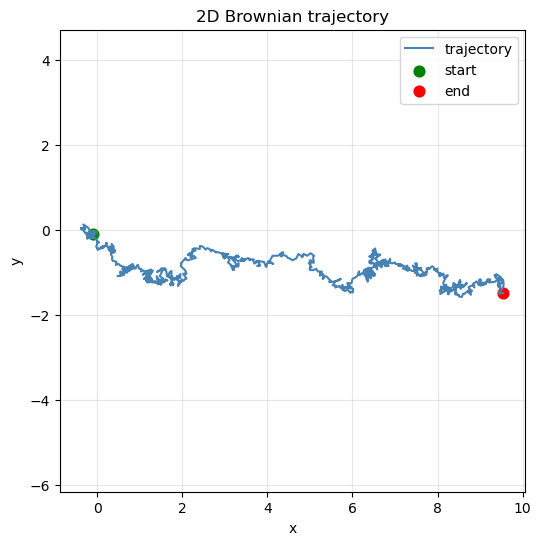

In [28]:
import matplotlib.pyplot as plt
import numpy as np

traj = np.asarray(trajectory[:, 0, :])

plt.figure(figsize=(6, 6))
plt.plot(traj[:, 0], traj[:, 1], lw=1.5, color="steelblue", label="trajectory")
plt.scatter(traj[0, 0], traj[0, 1], color="green", s=60, label="start")
plt.scatter(traj[-1, 0], traj[-1, 1], color="red", s=60, label="end")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Brownian trajectory")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
import jax.numpy as jnp
from jax import random, lax, jit
from jax_md import simulate

F_body = jnp.array([-0.008e-12, 0.858e-12], dtype=jnp.float64)
Tau_body = jnp.float64(0.909e-3 * 1e-15)
generalized_force_body = jnp.array([F_body[0], F_body[1], Tau_body], dtype=jnp.float64)

gamma_T = jnp.float64(470e-9)
gamma_R = jnp.float64(8000e-21)
k_BT = jnp.float64(1.38e-23 * 300.0)
delta_t = jnp.float64(1000e-6)
n_timesteps = 200_000

def build_rotation_3x3(theta):
    c = jnp.cos(theta)
    s = jnp.sin(theta)
    return jnp.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ], dtype=jnp.float64)

def force_fn(q):
    theta = q[0, 2]
    B = build_rotation_3x3(theta)
    return (B @ generalized_force_body)[None, :]

def shift_fn(q, dq, **kwargs):
    q_new = q + dq
    theta = (q_new[..., 2] + jnp.pi) % (2 * jnp.pi) - jnp.pi
    return q_new.at[..., 2].set(theta)

q0 = jnp.array([[0.0, 0.0, 0.0]], dtype=jnp.float64)
gamma = jnp.array([[gamma_T, gamma_T, gamma_R]], dtype=jnp.float64)

init_fn, step_fn = simulate.brownian(
    force_fn,
    shift_fn,
    dt=delta_t,
    kT=k_BT,
    gamma=gamma,
)
step_fn = jit(step_fn)

state = init_fn(random.PRNGKey(0), q0, mass=1.0)

def scan_step(state, _):
    state = step_fn(state)
    return state, state.position

state, trajectory = lax.scan(scan_step, state, xs=None, length=n_timesteps)


In [18]:
import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
import jax.numpy as jnp
from jax import random, lax, jit,grad,vmap
from jax_md import simulate,energy,space

def rotation_2d(theta):
    c = jnp.cos(theta)
    s = jnp.sin(theta)
    return jnp.array([[c, -s],
                      [s,  c]], dtype=theta.dtype)

def lab_to_body_force(theta, F_lab):
    #transpose because rotation matrix orthogonal so lab to body is inverse
    return rotation_2d(theta).T @ F_lab

# F_body_const = jnp.array(
#     [-0.008e-12, 0.858e-12, 0.909e-3 * 1e-15],
#     dtype=jnp.float64,
# )
# def force_fn_body(q, **kwargs):
#     return jnp.broadcast_to(F_body_const, q.shape)

R_body = jnp.array([
    [470e-9, 0.0, 0],
    [0.0, 470e-9, 0],
    [0, 0, 8000e-21],
], dtype=jnp.float64)

delta_t = jnp.float64(1000e-6)
n_timesteps = 200_000

def shift_generalized_2d(q, dq, **kwargs):
    q_new = q + dq
    theta = (q_new[..., 2] + jnp.pi) % (2 * jnp.pi) - jnp.pi
    return q_new.at[..., 2].set(theta)

#Define interaction between point like particles
displacement_fn, _ = space.free()

pair_energy_fn = energy.soft_sphere_pair(
    displacement_fn,
    sigma=2.0e-6,
    epsilon=1.0e-18,
    alpha=2.0,
)

def energy_fn_centers(q):
    R = q[:, :2]
    return pair_energy_fn(R)

grad_energy_fn = grad(energy_fn_centers)

def force_fn_body(q, **kwargs):
    g = grad_energy_fn(q)
    #translational force in lab frame
    F_lab = -g[:, :2]
    tau_lab = jnp.zeros((q.shape[0],), dtype=q.dtype)

    theta = q[:, 2]
    #vmap over all particles
    F_body =vmap(lab_to_body_force)(theta,F_lab)

    #create force for all particles
    F_active_body = jnp.broadcast_to(
        jnp.array([0.0, 0.0], dtype=q.dtype),
        (q.shape[0], 2),
    )
    #create torque for all particles
    tau_active_body = jnp.full(
        (q.shape[0],),
        0.0,
        dtype=q.dtype,
    )
    #turn torque from (N,) to (N,1) and then concatenate (N, 2)  +  (N, 1)  ->  (N, 3)
    return jnp.concatenate(
        [F_body + F_active_body, (tau_lab + tau_active_body)[:, None]],
        axis=1,
    )

def total_energy_fn(q, k_trap=1e-7):
    R = q[:, :2]
    U_rep = pair_energy_fn(R)
    U_trap = 0.5 * k_trap * jnp.sum(R**2)
    return  U_trap

grad_energy_fn = grad(total_energy_fn)

def force_fn_body(q, **kwargs):
    g = grad_energy_fn(q)
    F_lab = -g[:, :2]
    tau_lab = jnp.zeros((q.shape[0],), dtype=q.dtype)

    theta = q[:, 2]
    F_body = vmap(lab_to_body_force)(theta, F_lab)

    return jnp.concatenate([F_body, tau_lab[:, None]], axis=1)



init_fn, step_fn = simulate.brownian_generalized_2d(
    force_fn_body=force_fn_body,
    shift_fn=shift_generalized_2d,
    dt=100e-6,
    kT=0,
    resistance_body=R_body,
)

# q0 = jnp.array([
#     [0.0e-6, 0.0e-6, 0.0],
#     [1.0e-6, 0.0e-6, 0.0],
# ], dtype=jnp.float64)

q0 = jnp.array([
    [ 8.0e-6,  0.0e-6, 0.0],
    [-8.0e-6,  0.0e-6, 0.0],
    [ 0.0e-6,  8.0e-6, 0.0],
    [ 0.0e-6, -8.0e-6, 0.0],
], dtype=jnp.float64)
state = init_fn(random.PRNGKey(0), q0)
print(state)

def scan_step(state, _):
    state = step_fn(state)
    return state, state.position

state, trajectory = lax.scan(scan_step,state,xs=None,length=200000)


trajectory.shape

BrownianGeneralized2DState(position=Array([[ 8.e-06,  0.e+00,  0.e+00],
       [-8.e-06,  0.e+00,  0.e+00],
       [ 0.e+00,  8.e-06,  0.e+00],
       [ 0.e+00, -8.e-06,  0.e+00]], dtype=float64), rng=Array([0, 0], dtype=uint32))


(200000, 4, 3)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

traj_xy_um = np.asarray(trajectory[:, :, :2])*1e6

target_frames = 400
skip = max(1, traj_xy_um.shape[0] // target_frames)
traj_small = traj_xy_um[::skip]

xmin, ymin = traj_small.reshape(-1, 2).min(axis=0)
xmax, ymax = traj_small.reshape(-1, 2).max(axis=0)
pad = 0.1 * max(xmax - xmin, ymax - ymin, 1e-3)

fig, ax = plt.subplots(figsize=(6, 6))
scat = ax.scatter(traj_small[0, :, 0], traj_small[0, :, 1], s=40)
ax.set_aspect("equal")
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")

def init():
    scat.set_offsets(traj_small[0])
    ax.set_title("frame 0")
    return scat,

def update(frame):
    scat.set_offsets(traj_small[frame])
    ax.set_title(f"frame {frame}")
    return scat,

ani = FuncAnimation(
    fig,
    update,
    frames=traj_small.shape[0],
    init_func=init,
    interval=30,
    blit=True,
)

plt.close(fig)
HTML(ani.to_jshtml())



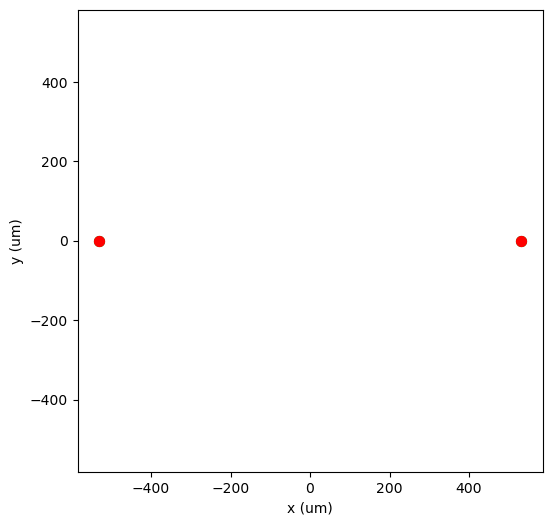

In [3]:
traj_xy_um = np.asarray(trajectory[:, :, :2])

target_frames = 400
skip = max(1, traj_xy_um.shape[0] // target_frames)
traj_small = traj_xy_um[::skip]
plt.figure(figsize=(6, 6))
for i in range(traj_small.shape[1]):
    plt.plot(traj_small[:, i, 0], traj_small[:, i, 1], lw=1)
    plt.scatter(traj_small[0, i, 0], traj_small[0, i, 1], color="green", s=50)
    plt.scatter(traj_small[-1, i, 0], traj_small[-1, i, 1], color="red", s=50)
plt.axis("equal")
plt.xlabel("x (um)")
plt.ylabel("y (um)")
plt.show()

In [5]:
print(traj_small.shape)
print(traj_small[0])
print(traj_small[1])
print(traj_small[-1])
print(np.max(np.abs(traj_small[1] - traj_small[0])))


traj_xy_um = np.asarray(trajectory[:, :, :2]) * 1e6

print("q0 (um):")
print(np.asarray(q0[:, :2]) * 1e6)

for i in range(10):
    print(i, traj_xy_um[i])

(400, 2, 2)
[[-531.91489227    0.        ]
 [ 531.91489327    0.        ]]
[[-531.91489227    0.        ]
 [ 531.91489327    0.        ]]
[[-531.91489227    0.        ]
 [ 531.91489327    0.        ]]
0.0
q0 (um):
[[0. 0.]
 [1. 0.]]
0 [[-5.31914892e+08  0.00000000e+00]
 [ 5.31914893e+08  0.00000000e+00]]
1 [[-5.31914892e+08  0.00000000e+00]
 [ 5.31914893e+08  0.00000000e+00]]
2 [[-5.31914892e+08  0.00000000e+00]
 [ 5.31914893e+08  0.00000000e+00]]
3 [[-5.31914892e+08  0.00000000e+00]
 [ 5.31914893e+08  0.00000000e+00]]
4 [[-5.31914892e+08  0.00000000e+00]
 [ 5.31914893e+08  0.00000000e+00]]
5 [[-5.31914892e+08  0.00000000e+00]
 [ 5.31914893e+08  0.00000000e+00]]
6 [[-5.31914892e+08  0.00000000e+00]
 [ 5.31914893e+08  0.00000000e+00]]
7 [[-5.31914892e+08  0.00000000e+00]
 [ 5.31914893e+08  0.00000000e+00]]
8 [[-5.31914892e+08  0.00000000e+00]
 [ 5.31914893e+08  0.00000000e+00]]
9 [[-5.31914892e+08  0.00000000e+00]
 [ 5.31914893e+08  0.00000000e+00]]


## MSD TEST

log-log slope = 1.0026014696835968


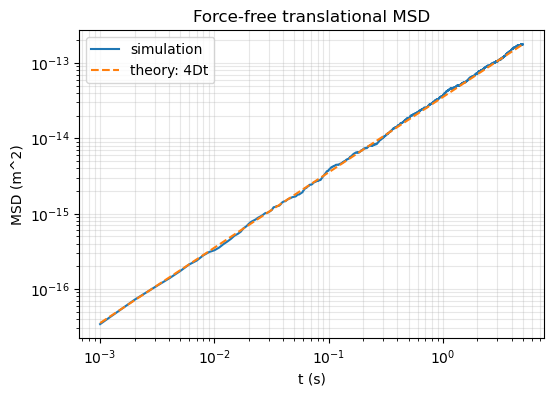

In [ ]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random, lax, vmap
from jax_md import simulate

def shift_generalized_2d(q, dq, **kwargs):
    q_new = q + dq
    theta = (q_new[..., 2] + jnp.pi) % (2 * jnp.pi) - jnp.pi
    return q_new.at[..., 2].set(theta)

def force_fn_body(q, **kwargs):
    return jnp.zeros_like(q)

gamma_T = jnp.float64(470e-9)
gamma_R = jnp.float64(8000e-21)
kT = jnp.float64(1.38e-23 * 300.0)
dt = jnp.float64(1e-3)

R_body = jnp.array([
    [gamma_T, 0.0, 0.0],
    [0.0, gamma_T, 0.0],
    [0.0, 0.0, gamma_R],
], dtype=jnp.float64)


init_fn, step_fn = simulate.brownian_generalized_2d(
    force_fn_body=force_fn_body,
    shift_fn=shift_generalized_2d,
    dt=dt,
    kT=kT,
    resistance_body=R_body,
)

n_steps = 5000
n_traj = 256

def run_trajectory(key):
    q0 = jnp.array([[0.0, 0.0, 0.0]], dtype=jnp.float64)
    state = init_fn(key, q0)

    def scan_step(state, _):
        state = step_fn(state)
        return state, state.position[0]

    _, traj = lax.scan(scan_step, state, xs=None, length=n_steps)
    return traj

keys = random.split(random.PRNGKey(0), n_traj)
trajectories = vmap(run_trajectory)(keys)   # shape (n_traj, n_steps, 3)

xy = trajectories[..., :2]
msd = jnp.mean(jnp.sum(xy**2, axis=-1), axis=0)

t = dt * jnp.arange(1, n_steps + 1)
msd_theory = 4.0 * (kT / gamma_T) * t

plt.figure(figsize=(6, 4))
plt.loglog(t, msd, label="simulation")
plt.loglog(t, msd_theory, "--", label="theory: 4Dt")
plt.xlabel("t (s)")
plt.ylabel("MSD (m^2)")
plt.title("Force-free translational MSD")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

coef = jnp.polyfit(jnp.log(t[100:]), jnp.log(msd[100:]), 1)
print("log-log slope =", float(coef[0]))

Simulating coupled particle (Triangle)...
Simulating uncoupled particle (Rectangle/Circle)...


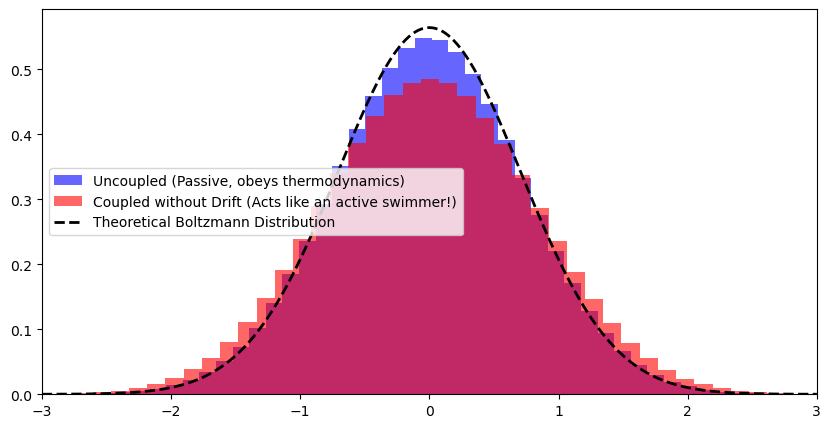

Theoretical Variance: 0.5
Uncoupled Variance: 0.5269510179287921
Coupled Variance: 0.6558302989863688


In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random, lax, vmap

# Importing your custom integrator exactly as it exists in your package
from jax_md import simulate

# --- 1. Helper Functions ---
def shift_generalized_2d(q, dq, **kwargs):
    q_new = q + dq
    # Keep angles wrapped between -pi and pi
    theta = (q_new[..., 2] + jnp.pi) % (2 * jnp.pi) - jnp.pi
    return q_new.at[..., 2].set(theta)

# --- 2. The Harmonic Trap Force ---
k_trap = jnp.float64(2e-6)  # Trap stiffness

def force_fn_body(q, **kwargs):
    # Pull particle to the center (0,0) with no torque
    F_lab = -k_trap * q.at[..., 2].set(0.0) 

    def rotate_force(theta, f_lab):
        c, s = jnp.cos(theta), jnp.sin(theta)
        R_inv = jnp.array([[ c, s, 0.0],
                           [-s, c, 0.0],
                           [0.0, 0.0, 1.0]])
        return R_inv @ f_lab

    return vmap(rotate_force)(q[..., 2], F_lab)

# --- 3. Simulation Parameters & Matrices ---
# --- EXAGGERATED TOY MODEL PARAMETERS ---
kT = jnp.float64(1.0)        # Huge temperature
dt = jnp.float64(0.05)       # Big time step
k_trap = jnp.float64(2.0)    # Strong trap

# Matrix WITH massive coupling
R_coupled = jnp.array([
    [1.0, 0.0, 0.8],
    [0.0, 1.0, 0.8],
    [0.8, 0.8, 2.0],
], dtype=jnp.float64)

# Matrix WITHOUT coupling
R_uncoupled = jnp.array([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 2.0],
], dtype=jnp.float64)

n_steps = 150000
n_traj = 256

# --- 4. Execution ---
def run_sim(resistance_matrix):
    # Calling your EXACT UNMODIFIED integrator from the package
    init_fn, step_fn = simulate.brownian_generalized_2d(
        force_fn_body=force_fn_body,
        shift_fn=shift_generalized_2d,
        dt=dt,
        kT=kT,
        resistance_body=resistance_matrix
    )
    
    @jax.jit
    def run_trajectory(key):
        # Split the key to generate random initial angles
        key, angle_key = random.split(key)
        
        # Start at origin (0, 0), but with a random angle between -pi and pi
        initial_theta = random.uniform(angle_key, minval=-jnp.pi, maxval=jnp.pi)
        q0 = jnp.array([[0.0, 0.0, initial_theta]], dtype=jnp.float64)
        
        state = init_fn(key, q0)

        def scan_step(state, _):
            state = step_fn(state)
            return state, state.position[0]

        _, traj = lax.scan(scan_step, state, xs=None, length=n_steps)
        return traj
    keys = random.split(random.PRNGKey(0), n_traj)
    return vmap(run_trajectory)(keys)

print("Simulating coupled particle (Triangle)...")
traj_coupled = run_sim(R_coupled)

print("Simulating uncoupled particle (Rectangle/Circle)...")
traj_uncoupled = run_sim(R_uncoupled)

# --- 5. Plotting ---
burn_in=3000
x_coupled = traj_coupled[:, burn_in:, 0].flatten()
x_uncoupled = traj_uncoupled[:, burn_in:, 0].flatten()

plt.figure(figsize=(10, 5))

# Plot the X positions
plt.hist(x_uncoupled, bins=60, density=True, alpha=0.6, color='blue', 
         label='Uncoupled (Passive, obeys thermodynamics)')
plt.hist(x_coupled, bins=60, density=True, alpha=0.6, color='red', 
         label='Coupled without Drift (Acts like an active swimmer!)')

# Theoretical Gaussian for the positional Boltzmann distribution
x_axis = jnp.linspace(-3, 3, 1000)
variance = kT / k_trap 
theory_curve = (1.0 / jnp.sqrt(2 * jnp.pi * variance)) * jnp.exp(-(x_axis**2) / (2 * variance))
plt.plot(x_axis, theory_curve, 'k--', linewidth=2, label='Theoretical Boltzmann Distribution')

plt.xlim(-3, 3)
plt.legend()
plt.show()

print(f"Theoretical Variance: {variance}")
print(f"Uncoupled Variance: {jnp.var(x_uncoupled)}")
print(f"Coupled Variance: {jnp.var(x_coupled)}")